In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from scipy import stats
import itertools
import seaborn as sns
from functools import reduce
import networkx as nx
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')
%matplotlib inline

# Visualization Function

In [2]:
def category_plotting_detailed(x, y, data, order):
    fig, ax = plt.subplots()
    sns.set(rc={"figure.figsize": (3, 5)})
    sns.set(font="Roboto")
    sns.set(font_scale=2)
    sns.set_style("white")

    sns.boxplot(x=x, y=y, data=data, palette=["gainsboro", "red"], order=order)

    sns.swarmplot(x=x, y=y, data=data, dodge=True, color="black", order=order)
    sns.despine()

    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, 0.7))

    return ax

# Data Import

import general behaviour scoring dataset

In [3]:
raw_df = pd.read_csv("negative_parental_switch_summary.csv", encoding="cp1252")

agg_cond_data_first = raw_df[
    (raw_df["exp_cond"].isin(["food_deprivation", "all_stressor_5h"]))
    & (raw_df["exp_time"] == 1)
]

import detailed behaviour analysis dataset

In [ ]:
df = pd.read_csv("observations.tsv", sep="\t")
df = pd.concat([df["Observation id"].str.split(",", expand=True), df], axis=1)
df = df.rename(columns={0: "id_1", 1: "id_2", 2: "phase"})
df.head()

,id_1,id_2,phase,Observation id,Observation date,Description,Media file,Total length,FPS,pre,...,Subject,Behavior,Behavioral category,Modifiers,Behavior type,Start (s),Stop (s),Duration (s),Comment start,Comment stop
0,BRAC4939.7c(R),BRAC4939.7e(L),test,"BRAC4939.7c(R),BRAC4939.7e(L),test",2021-03-14 13:27:47,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,935.244,29.99,NaN,...,right,pup introduction,NaN,NaN,POINT,8.452,8.452,NaN,NaN,NaN
1,BRAC4943.6b(R),BRAC5007.4d(L),test,"BRAC4943.6b(R),BRAC5007.4d(L),test",2021-03-14 13:28:54,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,1128.630,29.99,NaN,...,right,pup introduction,NaN,NaN,POINT,9.196,9.196,NaN,NaN,NaN
2,BRAC4895.5b(R),BRAC4895.5e(L),control,"BRAC4895.5b(R),BRAC4895.5e(L),control",2021-03-15 21:55:14,NaN,/home/tochenan/pups-20210315T115336Z-001/pups/...,946.470,29.99,NaN,...,right,pup introduction,NaN,NaN,POINT,9.453,9.453,NaN,NaN,NaN
3,BRAC4895.5b(R),BRAC4895.5e(L),test,"BRAC4895.5b(R),BRAC4895.5e(L),test",2021-03-14 12:31:29,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,960.657,29.99,NaN,...,right,pup introduction,NaN,NaN,POINT,9.954,9.954,NaN,NaN,NaN
4,BRAC4895.5b(R),BRAC4895.5e(L),control,"BRAC4895.5b(R),BRAC4895.5e(L),control",2021-03-15 21:55:14,NaN,/home/tochenan/pups-20210315T115336Z-001/pups/...,946.470,29.99,NaN,...,right,in empty nest,NaN,NaN,STATE,10.206,104.241,94.035,NaN,NaN


In [ ]:
right = df[
    ([df["id_1"][i][-3:] == "(R)" for i in range(len(df.id_1))])
    & (df["Subject"] == "right")
].reset_index()
left = df[
    ([df["id_2"][i][-3:] == "(L)" for i in range(len(df.id_2))])
    & (df["Subject"] == "left")
].reset_index()
right["mice_ID"] = [right["id_1"][i][0:-3] for i in range(len(right.id_1))]
left["mice_ID"] = [left["id_2"][i][0:-3] for i in range(len(left.id_2))]
right = right.drop(["id_1", "id_2", "Observation id"], axis=1)
left = left.drop(["id_1", "id_2", "Observation id"], axis=1)
df_cleaned = pd.concat([right, left]).reset_index()
df_cleaned.head()

,level_0,index,phase,Observation date,Description,Media file,Total length,FPS,pre,post,...,Behavior,Behavioral category,Modifiers,Behavior type,Start (s),Stop (s),Duration (s),Comment start,Comment stop,mice_ID
0,0,0,test,2021-03-14 13:27:47,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,935.244,29.99,NaN,NaN,...,pup introduction,NaN,NaN,POINT,8.452,8.452,NaN,NaN,NaN,BRAC4939.7c
1,1,1,test,2021-03-14 13:28:54,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,1128.630,29.99,NaN,NaN,...,pup introduction,NaN,NaN,POINT,9.196,9.196,NaN,NaN,NaN,BRAC4943.6b
2,2,2,control,2021-03-15 21:55:14,NaN,/home/tochenan/pups-20210315T115336Z-001/pups/...,946.470,29.99,NaN,NaN,...,pup introduction,NaN,NaN,POINT,9.453,9.453,NaN,NaN,NaN,BRAC4895.5b
3,3,3,test,2021-03-14 12:31:29,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,960.657,29.99,NaN,NaN,...,pup introduction,NaN,NaN,POINT,9.954,9.954,NaN,NaN,NaN,BRAC4895.5b
4,4,4,control,2021-03-15 21:55:14,NaN,/home/tochenan/pups-20210315T115336Z-001/pups/...,946.470,29.99,NaN,NaN,...,in empty nest,NaN,NaN,STATE,10.206,104.241,94.035,NaN,NaN,BRAC4895.5b


# Pre and Post phase data processing

In [6]:
df_test = df_cleaned[df_cleaned["phase"] == "test"]
df_control = df_cleaned[df_cleaned["phase"] == "control"]
df_test["corrected_start"] = df_test.groupby("mice_ID")["Start (s)"].transform(
    lambda x: (x - x.min())
)

df_control["corrected_start"] = df_control.groupby("mice_ID")["Start (s)"].transform(
    lambda x: (x - x.min())
)

df_test["contact_latency"] = df_test.groupby("mice_ID")["corrected_start"].transform(
    lambda x: (x.nsmallest(2).iloc[-1])
)
df_control["contact_latency"] = df_control.groupby("mice_ID")[
    "corrected_start"
].transform(lambda x: (x.nsmallest(2).iloc[-1]))

df_test_duration = (
    df_test.groupby(["mice_ID", "Behavior"])["Duration (s)"].sum().reset_index()
)
df_control_duration = (
    df_control.groupby(["mice_ID", "Behavior"])["Duration (s)"].sum().reset_index()
)
df_test_freq = df_test.groupby(["mice_ID", "Behavior"]).size().reset_index(name="n")
df_control_freq = (
    df_control.groupby(["mice_ID", "Behavior"]).size().reset_index(name="n")
)

df_test_p = df_test_duration.merge(
    df_test_freq, how="outer", on=["mice_ID", "Behavior"]
)
df_test_p = df_test_p.merge(
    df_test.filter(["mice_ID", "contact_latency"], axis=1).drop_duplicates(),
    how="left",
    on="mice_ID",
)
df_control_p = df_control_duration.merge(
    df_control_freq, how="outer", on=["mice_ID", "Behavior"]
)
df_control_p = df_control_p.merge(
    df_control.filter(["mice_ID", "contact_latency"], axis=1).drop_duplicates(),
    how="left",
    on="mice_ID",
)

df_test_p = df_test_p.merge(
    agg_cond_data_first.filter(["mice_ID", "estrous_stage", "state_after"]),
    how="left",
    on="mice_ID",
)
df_control_p = df_control_p.merge(
    agg_cond_data_first.filter(
        ["mice_ID", "estrous_stage", "state_after", "retrieval_before_latency"]
    ),
    how="left",
    on="mice_ID",
)

# visualize behaviour data

In [7]:
def preprocess_behaviour(bdf, frame_rate=29.99):
    """
    Preprocess behavior data to create binary arrays for each behavior.

    Parameters:
    - bdf (pd.DataFrame): Behavior DataFrame containing 'Behavior', 'Start (s)', 'Stop (s)', and 'Behavior type'.
    - frame_rate (float): Frame rate of the recording.

    Returns:
    - num_episodes (pd.DataFrame): Number of episodes for each behavior.
    - bdf_p (pd.DataFrame): Binary arrays for each behavior.
    - events (list): Non-zero indices for each behavior.
    """
    # Extract behavior names
    behavs = bdf["Behavior"].unique()

    # Initialize empty results
    num_episodes = pd.DataFrame()
    bdf_p = pd.DataFrame()
    events = []

    # Construct a binary ON/OFF array for each behavior
    for n, behav in enumerate(behavs):
        behav_data = bdf.loc[bdf["Behavior"] == behav, :]

        # Convert start and stop times to frame indices
        starts = (behav_data["Start (s)"] * frame_rate).round().astype(int)
        stops = (behav_data["Stop (s)"] * frame_rate).round().astype(int)

        try:
            binary = np.zeros(
                (behav_data["Total length"].iloc[0] * frame_rate).round().astype(int),
                dtype=int,
            )
        except KeyError:
            binary = np.zeros(
                (behav_data["Total duration"].iloc[0] * frame_rate).round().astype(int),
                dtype=int,
            )

        # Create binary array
        if behav_data["Behavior type"].iloc[0] == "POINT":
            point = (behav_data["Start (s)"] * frame_rate).round().astype(int)
            binary[point - 1] = 1  # Adjust for zero-based indexing
        else:
            for start, stop in zip(starts, stops):
                binary[start:stop] = 1

        # Record the number of episodes and binary array
        num_episodes.loc[0, behavs[n]] = len(starts)
        bdf_p[behavs[n]] = binary

        # Save non-zero indices
        events.append(binary.nonzero()[0])

    return num_episodes, bdf_p, events

In [8]:
df_test_p[df_test_p["state_after"] == "Agg-"]["mice_ID"].unique()

array(['BRAC4673.7c', 'BRAC4895.5b', 'BRAC4895.5c', 'BRAC4895.5e',
       'BRAC4908.4f', 'BRAC4939.7e', 'BRAC5007.4d', 'BRAC5077.5e',
       'BRAC5178.2i', 'BRAC5215.1c'], dtype=object)

In [14]:
# plot ethogram
example_mice = "BRAC5178.2i"
example_behavior = df_cleaned[
    (df_cleaned["mice_ID"] == example_mice) & (df_cleaned["phase"] == "test")
]
episode, bdf, events = preprocess_behaviour(example_behavior)
events = events[:-1]
end = max(event.max() for event in events)

behavs = bdf.columns.tolist()
behavs.remove("trial end")

In [10]:
# plot ethogram for cannulation data
cann_df = pd.read_csv("../NPW_manipulation/cannulation_annotation.tsv", sep="\t")

example_mice = "BRAC9442.3i_ZD"
example_behavior = cann_df[(cann_df["Observation id"] == example_mice)]
episode, bdf, events = preprocess_behaviour(example_behavior)
events = events[:-1]
end = max(event.max() for event in events)

behavs = bdf.columns.tolist()
behavs.remove("self-grooming")

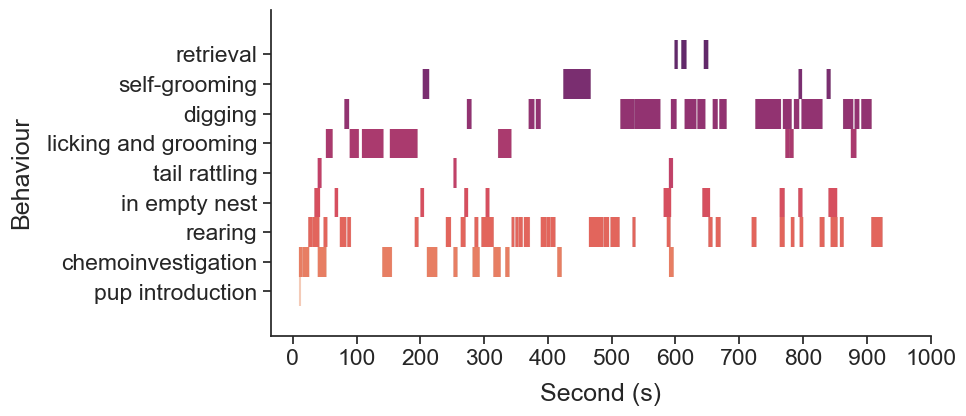

In [15]:
sns.set(font_scale=1.5, style="ticks")
fig, ax = plt.subplots(
    figsize=(10, len(behavs) / 2)
)  # Adjust figure height to fit rows
behav_colors = sns.color_palette("flare", len(behavs))

for j, event in enumerate(events):
    ax.eventplot(
        event,
        linelengths=1,
        color=behav_colors[j],
        lineoffsets=j,  # Offset each behavior by its index
        alpha=0.5,
    )

# Customize plot
ax.set_yticks(range(len(behavs)))
ax.set_yticklabels(behavs)  # Label rows with behavior names

# Define the total duration in seconds (end) and frame rate
frame_rate = 29.99
total_seconds = end / frame_rate  # Convert total frames to seconds

# Define x-ticks at every 100 seconds
tick_interval_seconds = 100
xticks_seconds = np.arange(
    0, total_seconds + tick_interval_seconds, tick_interval_seconds
)
xticks_frames = (xticks_seconds * frame_rate).astype(
    int
)  # Convert seconds to frame indices

# Set x-ticks and labels
ax.set_xticks(xticks_frames)  # Tick positions in frame indices
ax.set_xticklabels(xticks_seconds.astype(int))  # Tick labels in seconds
ax.set_xlabel("Time (s)")


ax.set_xlabel("Second (s)", labelpad=10)
ax.set_ylabel("Behaviour", labelpad=10)
sns.despine()
plt.tight_layout()
plt.savefig(
    f"{example_mice}_ethogram.png", dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

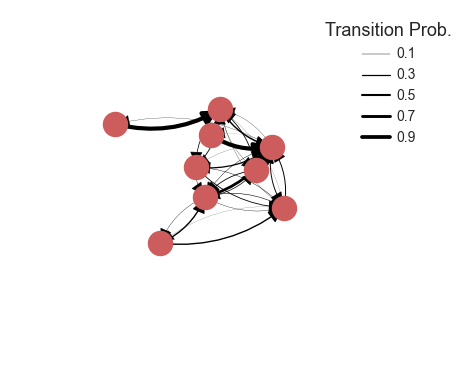

In [27]:
from matplotlib.patches import FancyArrowPatch

sequence = example_behavior.Behavior.tolist()
T = pd.crosstab(
    pd.Series(sequence[:-1], name="state1"),
    pd.Series(sequence[1:], name="state2"),
    normalize=0,
)

states = T.columns.tolist()
# states.remove('trial end')


# Create a directed graph using NetworkX
G = nx.DiGraph()

# Add nodes (states) to the graph
G.add_nodes_from(states)

edge_widths = []  # List to store edge widths
for from_state in states:
    for to_state in states:
        try:
            transition_prob = T.loc[from_state, to_state]
        except Exception as e:
            continue
        if transition_prob > 0:  # Only add edges with non-zero probability
            G.add_edge(from_state, to_state, weight=transition_prob)
            edge_widths.append(
                transition_prob * 10
            )  # Scale transition_prob for visual clarity


# Generate the initial layout and scale node positions
def scale_positions(pos, scale_factor=0.6):
    center = np.mean(list(pos.values()), axis=0)
    return {
        node: center + scale_factor * (coords - center) for node, coords in pos.items()
    }


# Function to calculate arrow start and end points based on node size
def get_arrow_points(from_pos, to_pos, node_size=3000):
    """
    Calculate the points where the arrow should start and end, based on the node size
    to ensure arrows do not overlap the nodes.
    """
    # Get the vector between the two nodes
    dx = to_pos[0] - from_pos[0]
    dy = to_pos[1] - from_pos[1]

    # Normalize the vector (direction of the arrow)
    dist = np.sqrt(dx**2 + dy**2)
    unit_dx, unit_dy = dx / dist, dy / dist

    # Adjust the positions to start and end at the node perimeter
    from_arrow = (
        from_pos[0] + unit_dx * np.sqrt(node_size),
        from_pos[1] + unit_dy * np.sqrt(node_size),
    )
    to_arrow = (
        to_pos[0] - unit_dx * np.sqrt(node_size),
        to_pos[1] - unit_dy * np.sqrt(node_size),
    )

    return from_arrow, to_arrow


original_pos = nx.spring_layout(G, seed=42)
scaled_pos = scale_positions(original_pos, scale_factor=0.02)


# Draw nodes and labels
plt.figure(figsize=(5, 4))


def draw_bidirectional_edges(G, pos, ax, rad=0.2):
    drawn_edges = set()
    for from_node, to_node, edge_data in G.edges(data=True):
        weight = edge_data.get("weight", 1.0)
        arrow_width = weight * 3  # Scale arrow width by transition probability

        # Check if the reverse edge exists
        is_reverse_edge = (to_node, from_node) in G.edges and (
            to_node,
            from_node,
        ) not in drawn_edges

        # Adjust curvature for bidirectional edges
        if is_reverse_edge:
            rad_curved = rad if (from_node, to_node) not in drawn_edges else -rad
        else:
            rad_curved = rad  # Straight line for unidirectional edges

        # Draw the edge
        edge = FancyArrowPatch(
            pos[from_node],
            pos[to_node],
            connectionstyle=f"arc3,rad={rad_curved}",
            arrowstyle="-|>",
            color="black",
            linewidth=arrow_width,
            mutation_scale=20,  # Arrowhead size
        )
        ax.add_patch(edge)

        # Mark the edge as drawn
        drawn_edges.add((from_node, to_node))


# Add curved edges to the plot
ax = plt.gca()
# Draw edges first to ensure they're on top of the nodes
draw_bidirectional_edges(G, scaled_pos, ax, rad=0.2)
# Draw nodes and labels after edges
nx.draw_networkx_nodes(
    G, scaled_pos, node_color="indianred", ax=ax
)  # Increased node size
# nx.draw_networkx_labels(G, scaled_pos, font_size=10, font_weight="bold", ax=ax)

from matplotlib.lines import Line2D

# Create legend handles for different transition probabilities
legend_probs = [0.1, 0.3, 0.5, 0.7, 0.9]
legend_lines = [
    Line2D([0], [0], color="black", linewidth=p * 3, label=f"{p:.1f}")
    for p in legend_probs
]

# Add the legend to the plot
ax.legend(
    handles=legend_lines,
    title="Transition Prob.",
    bbox_to_anchor=(0.8, 1),
    fontsize=10,
    title_fontsize="13",
    frameon=False,
    handlelength=2,
    handletextpad=0.5,
)

# Title and display
plt.axis("off")
plt.tight_layout()
# plt.savefig(f'{example_mice}_transition_graph.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(
    f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1.5/linked_figures/{example_mice}_transition_graph.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)
plt.show()

# interaggression latency calculation

In [107]:
def calculate_iai(df):
    start = df["Start (s)"]
    end = df["Stop (s)"]
    if len(start) <= 1:
        return 0
    iai = start[1:].reset_index(drop=True) - end[:-1].reset_index(drop=True)
    return iai.mean()


agg_df = df_test[df_test.Behavior == "aggressive contact"]
iais = {}
for id in agg_df.mice_ID.unique():
    sub_df = agg_df[agg_df.mice_ID == id]
    iais[id] = calculate_iai(sub_df)

for id in cann_df["Observation id"].unique():
    sub_df = cann_df[
        (cann_df["Observation id"] == id)
        & (cann_df["Behavior"] == "aggressive contact")
    ]
    iais[id] = calculate_iai(sub_df)
iais = pd.DataFrame.from_dict(iais, orient="index", columns=["IAI (s)"])
iais = iais.reset_index().rename(columns={"index": "mice_ID"})
iais["group"] = iais["mice_ID"].apply(
    lambda x: "ZD" if x in cann_df["Observation id"].unique() else "Food Dep."
)

In [111]:
iais

,mice_ID,IAI (s),group
0,BRAC4939.7c,0.000000,Food Dep.
1,BRAC4895.5d,3.186667,Food Dep.
2,BRAC4943.6b,2.612500,Food Dep.
3,BRAC4673.7b,8.376000,Food Dep.
4,BRAC5077.5d,2.500000,Food Dep.
5,BRAC4939.7d,0.000000,Food Dep.
6,BRAC5077.5b,29.877500,Food Dep.
7,BRAC5007.4c,9.253000,Food Dep.
8,BRAC4908.4e,0.000000,Food Dep.
9,BRAC5077.5a,0.500000,Food Dep.


In [109]:
stats.mannwhitneyu(
    iais[iais["group"] == "ZD"]["IAI (s)"],
    iais[iais["group"] == "Food Dep."]["IAI (s)"],
)

MannwhitneyuResult(statistic=31.0, pvalue=0.597525010254158)

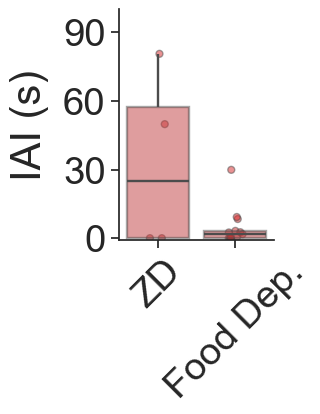

In [110]:
sns.set(rc={"figure.figsize": (2, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="group",
    y="IAI (s)",
    data=iais,
    palette=["Tab:red", "Tab:red"],
    boxprops=dict(alpha=0.5),
    order=["ZD", "Food Dep."],
    showcaps=False,
    showfliers=False,
    linewidth=1.7,
)

ax = sns.stripplot(
    x="group",
    y="IAI (s)",
    data=iais,
    palette=["Tab:red", "Tab:red"],
    order=["ZD", "Food Dep."],
    alpha=0.5,
    marker="o",
    size=5,
    linewidth=1,
    zorder=1,
    edgecolor="gray",
)


sns.despine()
plt.xlabel("")
plt.xticks(rotation=45)
plt.ylabel("IAI (s)", labelpad=10)
plt.ylim(-1, 100)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.savefig("output_figures/iai.png", dpi=600, bbox_inches="tight", transparent=True)

# Thresholding Parening and Ignoring mice

In [13]:
behaviors = [
    "chemoinvestigation",
    "licking and grooming",
    "retrieval",
    "nest building",
    "in nest",
    "in empty nest",
    "tail rattling",
    "rearing",
    "digging",
    "self-grooming",
]

parental_beh = ["licking and grooming", "retrieval", "nest building", "in nest"]

In [14]:
parental_duration = df_control_duration.loc[
    df_control_duration.Behavior.isin(parental_beh)
]
parental_duration = (
    parental_duration.groupby(["mice_ID"])["Duration (s)"]
    .sum()
    .reset_index(name="parental_time")
)
parental_duration = pd.merge(
    parental_duration,
    agg_cond_data_first.filter(
        ["mice_ID", "estrous_stage", "state_after", "parental_state_after"], axis=1
    ),
    how="left",
    on="mice_ID",
)

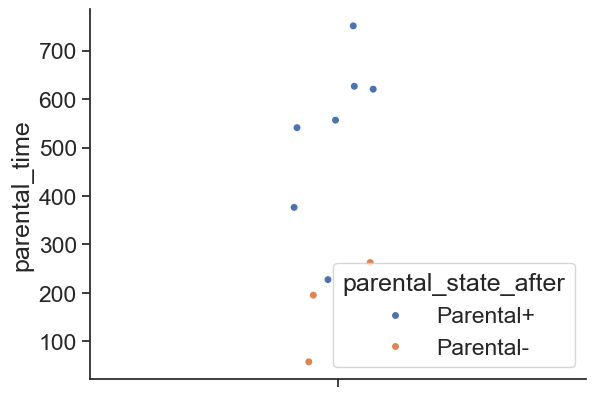

In [15]:
ax = sns.stripplot(
    y=parental_duration["parental_time"], hue=parental_duration["parental_state_after"]
)
sns.despine()

# Estrous cycle effect on different parental behaviour parameters

difference in behaviour duration and estrous cycle

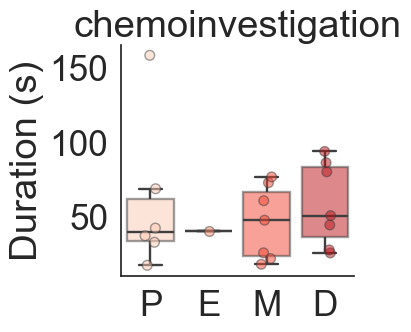

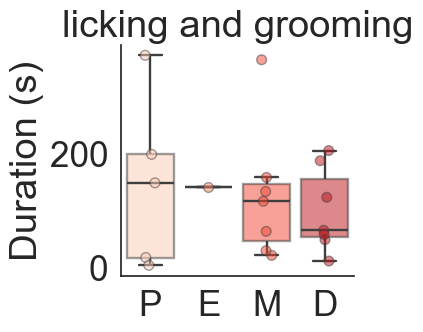

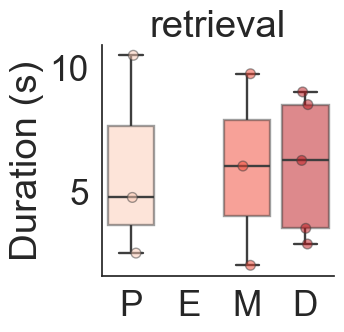

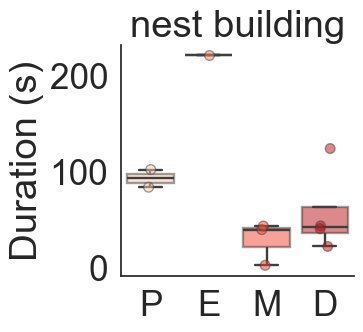

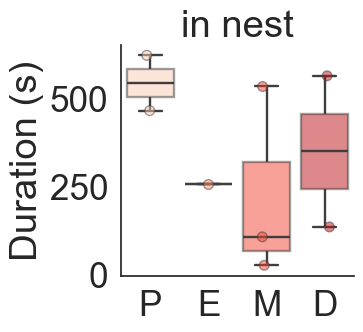

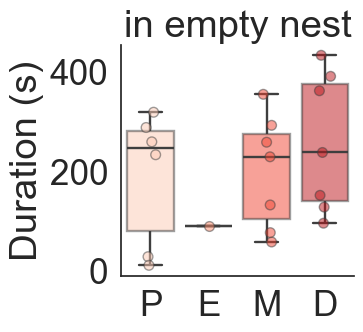

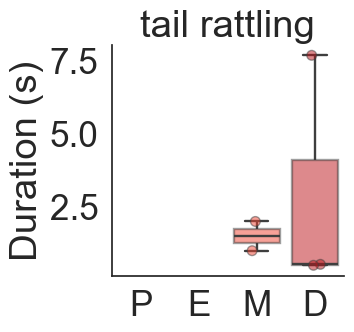

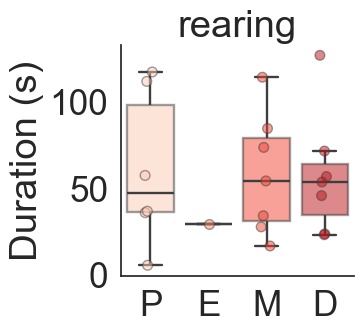

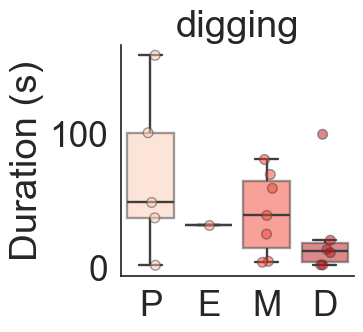

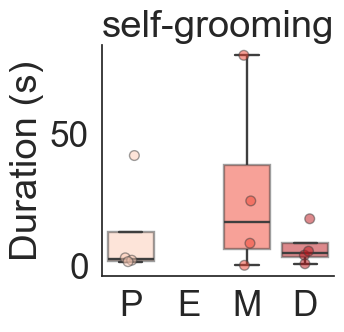

In [25]:
for behavior in behaviors:
    sns.set(font_scale=2.3)
    sns.set_style("white")
    plt.subplots(figsize=(3, 3))

    sns.boxplot(
        x="estrous_stage",
        y="Duration (s)",
        data=df_control_p[df_control_p["Behavior"] == behavior],
        order=["P", "E", "M", "D"],
        palette="Reds",
        saturation=8,
        linewidth=1.7,
        showfliers=False,
        boxprops=dict(alpha=0.5),
    )

    sns.stripplot(
        x="estrous_stage",
        y="Duration (s)",
        data=df_control_p[df_control_p["Behavior"] == behavior],
        dodge=False,
        order=["P", "E", "M", "D"],
        palette="Reds",
        jitter=True,
        marker="o",
        size=7,
        linewidth=1,
        edgecolor="gray",
        alpha=0.5,
    )

    plt.title(behavior)
    plt.xlabel("")

    sns.despine()

difference in behaviour frequency and estrous cycle

/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) 

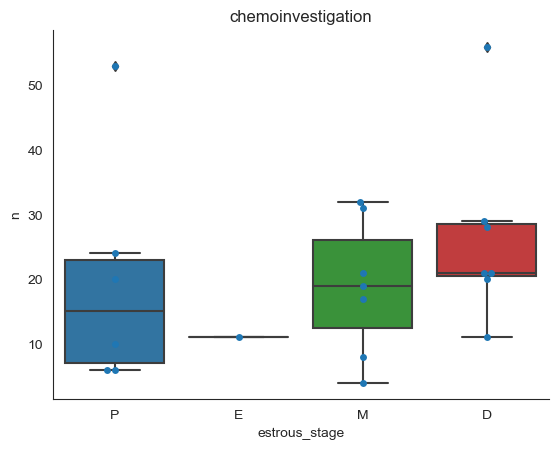

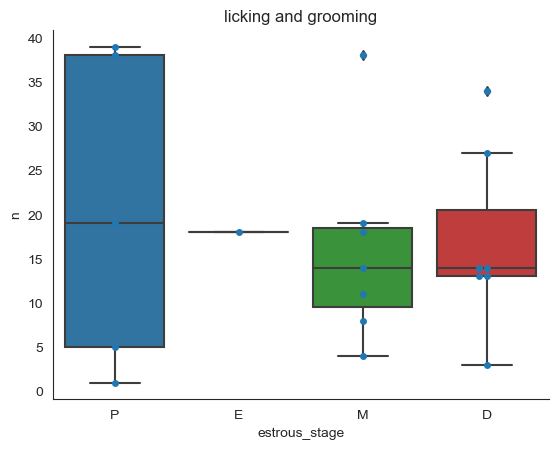

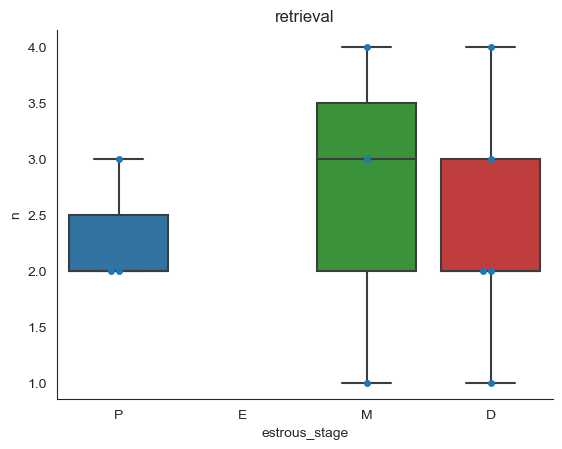

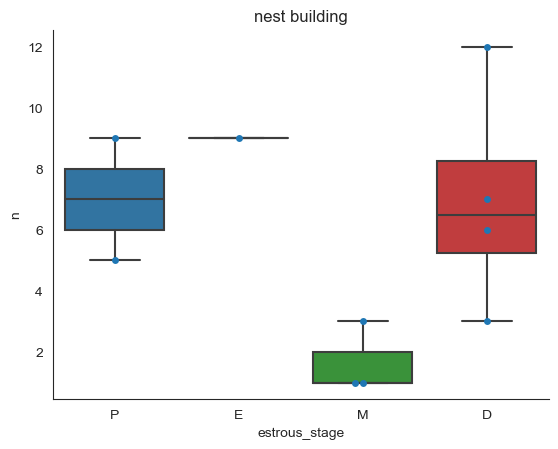

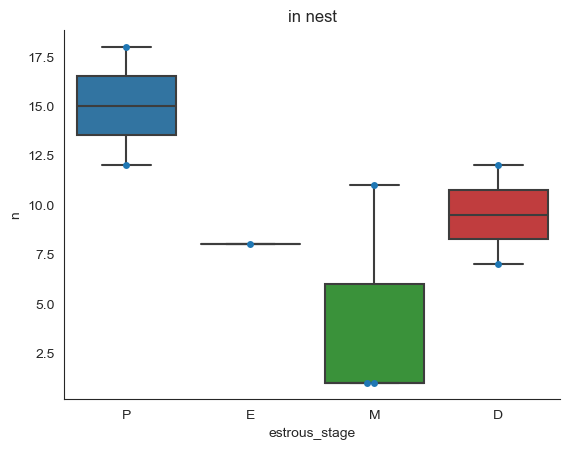

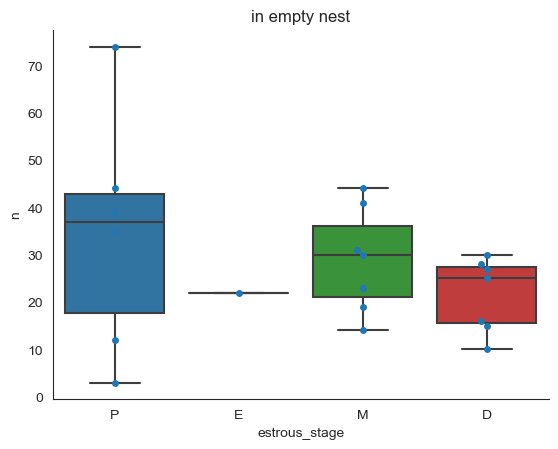

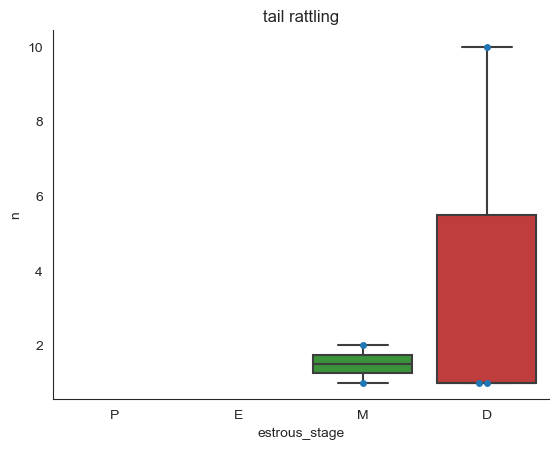

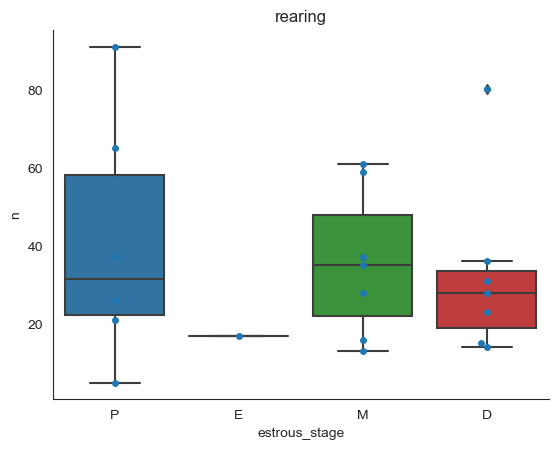

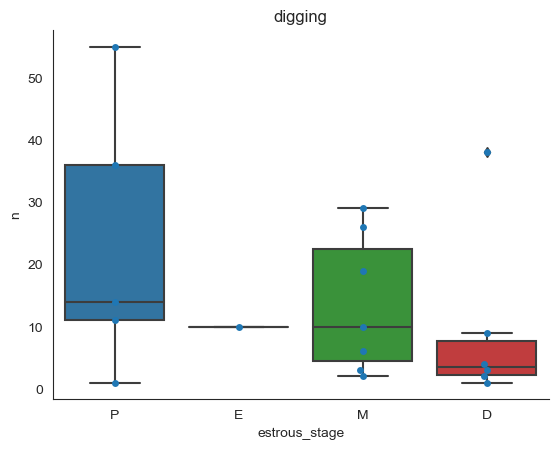

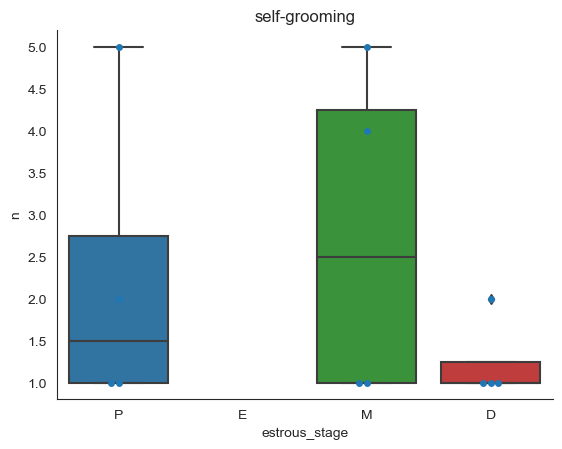

In [11]:
for behavior in behaviors:
    fig, ax = plt.subplots()
    sns.set_style("white")

    sns.boxplot(
        x="estrous_stage",
        y="n",
        data=df_control_p[df_control_p["Behavior"] == behavior],
        order=["P", "E", "M", "D"],
    )

    sns.swarmplot(
        x="estrous_stage",
        y="n",
        data=df_control_p[df_control_p["Behavior"] == behavior],
        dodge=True,
        order=["P", "E", "M", "D"],
    )

    plt.title(behavior)
    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, 0.7))

    sns.despine()

difference in latency and estrous cycle

/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) 

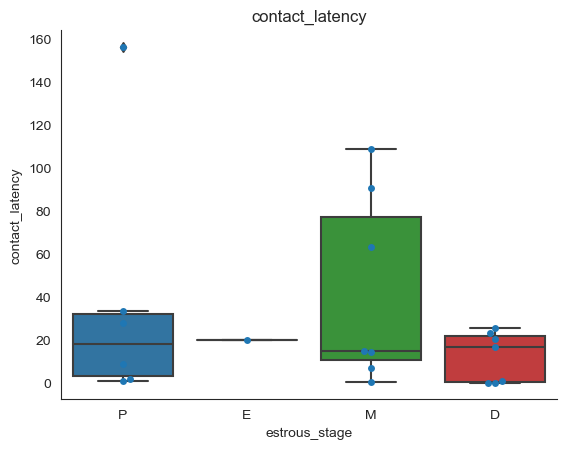

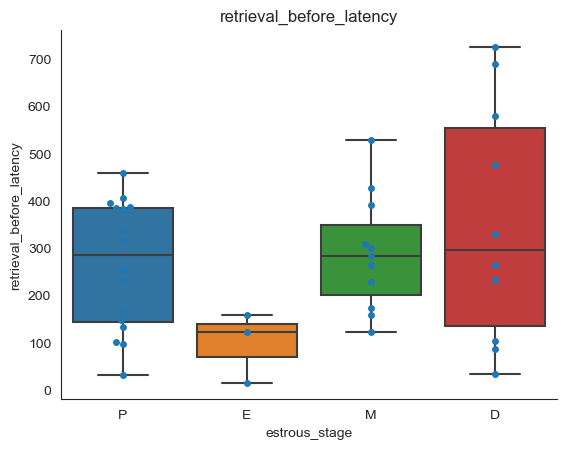

In [12]:
data_first = raw_df[raw_df["exp_time"] == 1]
lat = data_first.merge(
    df_control.filter(["mice_ID", "contact_latency"], axis=1).drop_duplicates(),
    how="outer",
    on="mice_ID",
)


for latency in ["contact_latency", "retrieval_before_latency"]:
    fig, ax = plt.subplots()
    sns.set_style("white")
    sns.boxplot(x="estrous_stage", y=latency, data=lat, order=["P", "E", "M", "D"])

    sns.swarmplot(x="estrous_stage", y=latency, data=lat, order=["P", "E", "M", "D"])

    plt.title(latency)

    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, 0.7))

    sns.despine()

differnce in percentage retrieval and estrous cycle stages

In [13]:
ret_per = (
    lat.groupby("estrous_stage")["retrieval_before_latency"]
    .apply(lambda x: x.notnull().mean())
    .reset_index(name="percentage")
)

/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) 

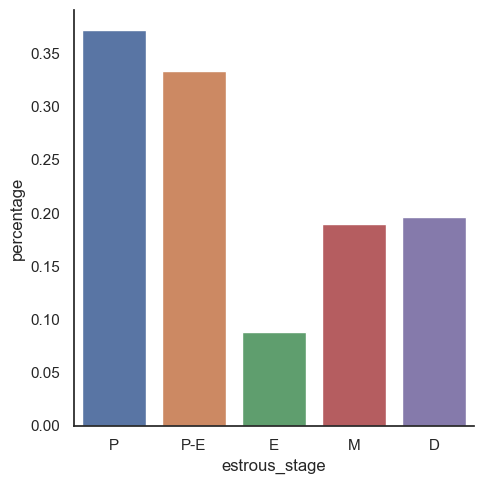

In [14]:
sns.set(rc={"figure.figsize": (5, 5)})
sns.set(font="Roboto")
sns.set_style("white")
g = sns.catplot(
    x="estrous_stage",
    y="percentage",
    kind="bar",
    data=ret_per,
    order=["P", "P-E", "E", "M", "D"],
)

# pre phase behaviour paramater and post phase aggression state

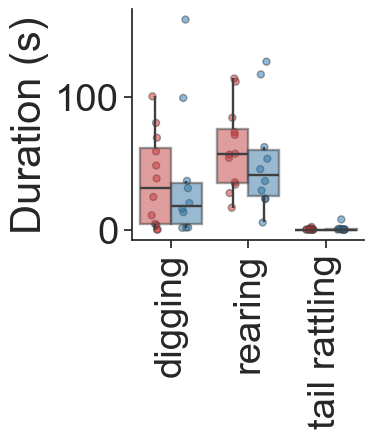

In [38]:
anxiety_beh = ["digging", "rearing", "tail rattling"]
behav_df = df_control_p[df_control_p["Behavior"].isin(anxiety_beh)]
agg_state = behav_df[["mice_ID", "state_after"]].drop_duplicates()

# Create a DataFrame of all combinations of `Animal` and `anxiety_beh`
all_combinations = pd.MultiIndex.from_product(
    [df_control_p["mice_ID"].unique(), anxiety_beh], names=["mice_ID", "Behavior"]
).to_frame(index=False)

# Merge with the original DataFrame to find missing combinations
complete_behav_df = pd.merge(
    all_combinations, behav_df, on=["mice_ID", "Behavior"], how="left"
)

# Fill missing behavior observations with 0
complete_behav_df["Duration (s)"].fillna(0, inplace=True)

complete_behav_df["state_after"] = complete_behav_df["mice_ID"].map(
    agg_state.set_index("mice_ID")["state_after"]
)


sns.set(rc={"figure.figsize": (3, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behavior",
    y="Duration (s)",
    hue="state_after",
    data=complete_behav_df,
    palette=["Tab:red", "Tab:blue"],
    boxprops=dict(alpha=0.5),
    order=anxiety_beh,
    showcaps=False,
    showfliers=False,
    linewidth=1.7,
)

ax = sns.stripplot(
    x="Behavior",
    y="Duration (s)",
    hue="state_after",
    data=complete_behav_df,
    palette=["Tab:red", "Tab:blue"],
    order=anxiety_beh,
    alpha=0.5,
    marker="o",
    dodge=True,
    size=5,
    linewidth=1,
    zorder=1,
    edgecolor="gray",
)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.3))


sns.despine()
# turn legend of
ax.get_legend().remove()
plt.xlabel("")
plt.ylabel("Duration (s)")
plt.xticks(rotation="vertical")
plt.savefig(
    "output_figures/control_anxiety_behaviour.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)
plt.savefig(
    "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/control_anxiety_behaviour.pdf",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)

In [19]:
# compute stats comparing the two states
for behavior in anxiety_beh:
    data = complete_behav_df[complete_behav_df["Behavior"] == behavior]
    print(
        stats.mannwhitneyu(
            data[data["state_after"] == "Agg+"]["Duration (s)"],
            data[data["state_after"] == "Agg-"]["Duration (s)"],
        )
    )

MannwhitneyuResult(statistic=64.0, pvalue=0.8174326180670027)
MannwhitneyuResult(statistic=73.0, pvalue=0.40981138833093633)
MannwhitneyuResult(statistic=53.0, pvalue=0.5594517042237296)


comparing contact latency between Agg+ and Agg- in pre and post phase

In [40]:
stat, p = stats.ttest_ind(
    df_control_p[df_control_p["state_after"] == "Agg+"][
        "contact_latency"
    ].drop_duplicates(),
    df_control_p[df_control_p["state_after"] == "Agg-"][
        "contact_latency"
    ].drop_duplicates(),
    equal_var=False,
)

stat, p1 = stats.ttest_ind(
    df_test_p[df_test_p["state_after"] == "Agg+"]["contact_latency"].drop_duplicates(),
    df_test_p[df_test_p["state_after"] == "Agg-"]["contact_latency"].drop_duplicates(),
    equal_var=False,
)


print(p, p1)

0.06694916575690803 0.01011686199708499


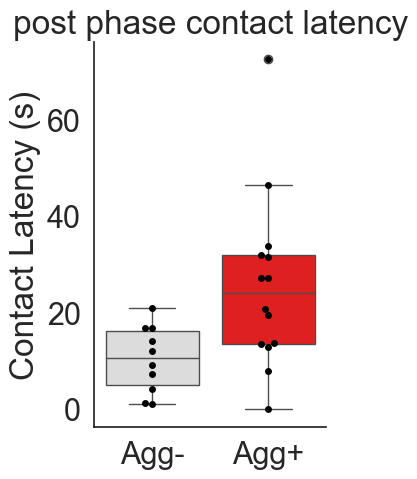

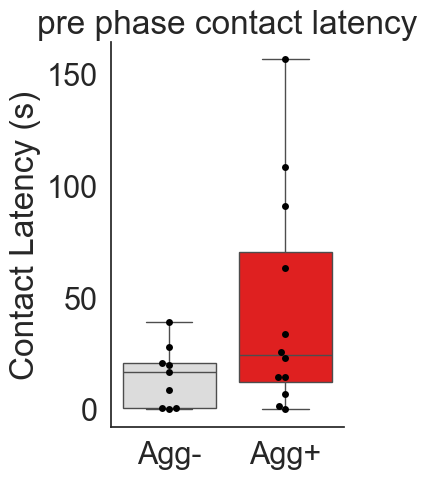

In [41]:
sns.set(rc={"figure.figsize": (3, 5)}, font_scale=2)
sns.set_style("white")

ax = category_plotting_detailed(
    "state_after",
    "contact_latency",
    df_test_p.filter(["contact_latency", "state_after"]).drop_duplicates(),
    ["Agg-", "Agg+"],
)
ax.set(ylabel="Contact Latency (s)")
ax.set_xlabel("")
plt.title("post phase contact latency")
plt.savefig(
    "output_figures/post_phase_contact_latency.jpg", dpi=300, bbox_inches="tight"
)

nobs = ["n = " + str(i) for i in [9, 13]]
pos = range(len(nobs))
"""
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            [25, 70][tick] + 5,
            nobs[tick],
            horizontalalignment='center',
            size='x-small',
            color='black')
"""
ax2 = category_plotting_detailed(
    "state_after",
    "contact_latency",
    df_control_p.filter(["contact_latency", "state_after"]).drop_duplicates(),
    ["Agg-", "Agg+"],
)
ax2.set(ylabel="Contact Latency (s)")
ax2.set_xlabel("")
plt.title("pre phase contact latency")
plt.savefig(
    "output_figures/pre_phase_contact_latency.jpg", dpi=300, bbox_inches="tight"
)

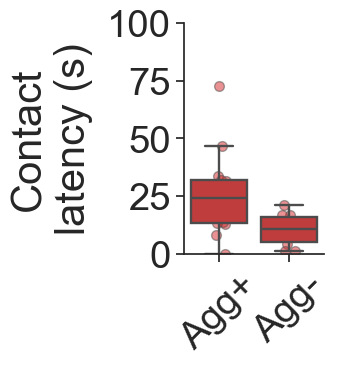

In [42]:
sns.set(rc={"figure.figsize": (1.8, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="state_after",
    y="contact_latency",
    data=df_test_p.filter(["contact_latency", "state_after"]).drop_duplicates(),
    order=["Agg+", "Agg-"],
    color="tab:red",
    showfliers=False,
    linewidth=1.7,
)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

ax = sns.stripplot(
    x="state_after",
    y="contact_latency",
    data=df_test_p.filter(["contact_latency", "state_after"]).drop_duplicates(),
    color="tab:red",
    alpha=0.5,
    zorder=1,
    edgecolor="gray",
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
)

ax.set(ylabel="Contact\nlatency (s)")
ax.yaxis.labelpad = 10
ax.set_xlabel("")
plt.ylim(0, 100)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
ax.set_xticklabels(("Agg+", "Agg-"), rotation=45)
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/post_phase_contact_latency.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

In [43]:
# Stats - U test
from scipy.stats import mannwhitneyu

df_filtered = df_test_p.filter(["contact_latency", "state_after"]).drop_duplicates()
data_agg_plus = df_filtered[df_filtered["state_after"] == "Agg+"]["contact_latency"]
data_agg_minus = df_filtered[df_filtered["state_after"] == "Agg-"]["contact_latency"]
statistic, p_value = mannwhitneyu(data_agg_plus, data_agg_minus)
print(statistic, p_value)

110.0 0.020729063227925355


MannwhitneyuResult(statistic=37.0, pvalue=0.13791345941250951)
MannwhitneyuResult(statistic=61.0, pvalue=0.6985353583033387)


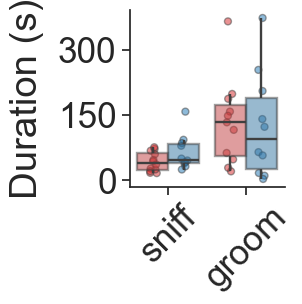

In [89]:
# pre phase chemoinvestigation and licking duration comparison

investigation_beh = ["chemoinvestigation", "licking and grooming"]


for behav in investigation_beh:
    print(
        stats.mannwhitneyu(
            df_control_p[
                (df_control_p["Behavior"] == behav)
                & (df_control_p["state_after"] == "Agg+")
            ]["Duration (s)"],
            df_control_p[
                (df_control_p["Behavior"] == behav)
                & (df_control_p["state_after"] == "Agg-")
            ]["Duration (s)"],
        )
    )


sns.set(font_scale=2.3)
sns.set_style("ticks")
plt.subplots(figsize=(2, 2.3))
ax = sns.boxplot(
    x="Behavior",
    y="Duration (s)",
    hue="state_after",
    data=df_control_p.loc[df_control_p["Behavior"].isin(investigation_beh)],
    palette=["Tab:red", "Tab:blue"],
    boxprops=dict(alpha=0.5),
    order=investigation_beh,
    showcaps=False,
    showfliers=False,
    linewidth=1.7,
)

ax = sns.stripplot(
    x="Behavior",
    y="Duration (s)",
    hue="state_after",
    data=df_control_p.loc[df_control_p["Behavior"].isin(investigation_beh)],
    palette=["Tab:red", "Tab:blue"],
    order=investigation_beh,
    alpha=0.5,
    marker="o",
    dodge=True,
    size=5,
    linewidth=1,
    zorder=1,
    edgecolor="gray",
)


plt.xticks([0, 1], ["sniff", "groom"])

ax.get_legend().remove()
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine()
plt.xticks(rotation=45)
plt.ylabel("Duration (s)", labelpad=10)
plt.xlabel("")
plt.savefig(
    "output_figures/pre_phase_chemoinvestigation_grooming.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

In [77]:
cut = 2 * 60
early_test = df_test[df_test["Start (s)"] < cut]

early_test_duration = (
    early_test.groupby(["mice_ID", "Behavior"])["Duration (s)"].sum().reset_index()
)
early_test_merged = early_test_duration.merge(
    agg_cond_data_first.filter(["mice_ID", "estrous_stage", "state_after"], axis=1),
    how="left",
    on="mice_ID",
)

MannwhitneyuResult(statistic=33.0, pvalue=0.5364994693194564)
MannwhitneyuResult(statistic=41.0, pvalue=0.6729740847387906)


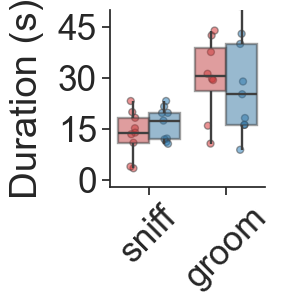

In [88]:
for behav in investigation_beh:
    print(
        stats.mannwhitneyu(
            early_test_merged[
                (early_test_merged["Behavior"] == behav)
                & (early_test_merged["state_after"] == "Agg+")
            ]["Duration (s)"],
            early_test_merged[
                (early_test_merged["Behavior"] == behav)
                & (early_test_merged["state_after"] == "Agg-")
            ]["Duration (s)"],
        )
    )


sns.set(font_scale=2.3)
sns.set_style("ticks")
plt.subplots(figsize=(2, 2.3))
ax = sns.boxplot(
    x="Behavior",
    y="Duration (s)",
    hue="state_after",
    data=early_test_merged,
    palette=["Tab:red", "Tab:blue"],
    boxprops=dict(alpha=0.5),
    order=investigation_beh,
    showcaps=False,
    showfliers=False,
    linewidth=1.7,
)

ax = sns.stripplot(
    x="Behavior",
    y="Duration (s)",
    hue="state_after",
    data=early_test_merged,
    palette=["Tab:red", "Tab:blue"],
    order=investigation_beh,
    alpha=0.5,
    marker="o",
    dodge=True,
    size=5,
    linewidth=1,
    zorder=1,
    edgecolor="gray",
)


plt.xticks([0, 1], ["sniff", "groom"])

ax.get_legend().remove()
plt.ylim(-2, 50)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine()
plt.xticks(rotation=45)
plt.ylabel("Duration (s)", labelpad=10)
plt.xlabel("")
plt.savefig(
    "output_figures/post_phase_chemoinvestigation_grooming.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)